In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
sns.set_theme(style="whitegrid")
plt.rcParams['axes.unicode_minus'] = False

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')
sample_submission = pd.read_csv('../data/sample_submission.csv')

print(f"Train sets: {train.shape}")
print(f"Test sets: {test.shape}")
train.head()

Train sets: (630000, 21)
Test sets: (270000, 20)


,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.920,32.580,1.010,3.050,15.010,50.610,725.990,5.900,16.790,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.820,No,112.160,East,Low
1,1,Clay,7.080,56.610,0.440,2.000,22.920,67.860,985.660,6.980,3.390,Wheat,Vegetative,Kharif,Rainfed,River,5.270,Yes,47.160,South,Low
2,2,Clay,5.690,27.710,0.810,2.830,26.970,92.220,2201.700,6.050,3.850,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.240,Yes,110.380,North,Low
3,3,Sandy,5.650,13.320,1.330,0.870,13.320,61.570,1357.330,9.120,2.310,Wheat,Flowering,Kharif,Canal,River,8.320,Yes,53.850,South,Medium
4,4,Clay,7.960,59.140,0.380,0.960,20.220,91.110,1538.200,6.950,13.940,Wheat,Sowing,Rabi,Canal,River,7.370,No,93.190,South,Low


In [2]:
print(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-null  object 
 14  Irri

In [3]:
print(train.describe())

              id    Soil_pH  Soil_Moisture  Organic_Carbon  \
count 630000.000 630000.000     630000.000      630000.000   
mean  314999.500      6.482         37.304           0.923   
std   181865.479      0.923         16.377           0.366   
min        0.000      4.800          8.000           0.300   
25%   157499.750      5.690         23.340           0.610   
50%   314999.500      6.440         37.750           0.910   
75%   472499.250      7.270         51.270           1.220   
max   629999.000      8.200         64.990           1.600   

       Electrical_Conductivity  Temperature_C   Humidity  Rainfall_mm  \
count               630000.000     630000.000 630000.000   630000.000   
mean                     1.745         26.998     61.563     1462.208   
std                      0.952          8.624     19.708      612.990   
min                      0.100         12.000     25.000        0.380   
25%                      0.930         19.517     45.390      954.570   
50%

In [4]:
print(train.isnull().sum())

id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64


In [12]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
cat_cols = train.select_dtypes(include=['object']).columns

for col in cat_cols:
    train[col] = le.fit_transform(train[col].astype(str))

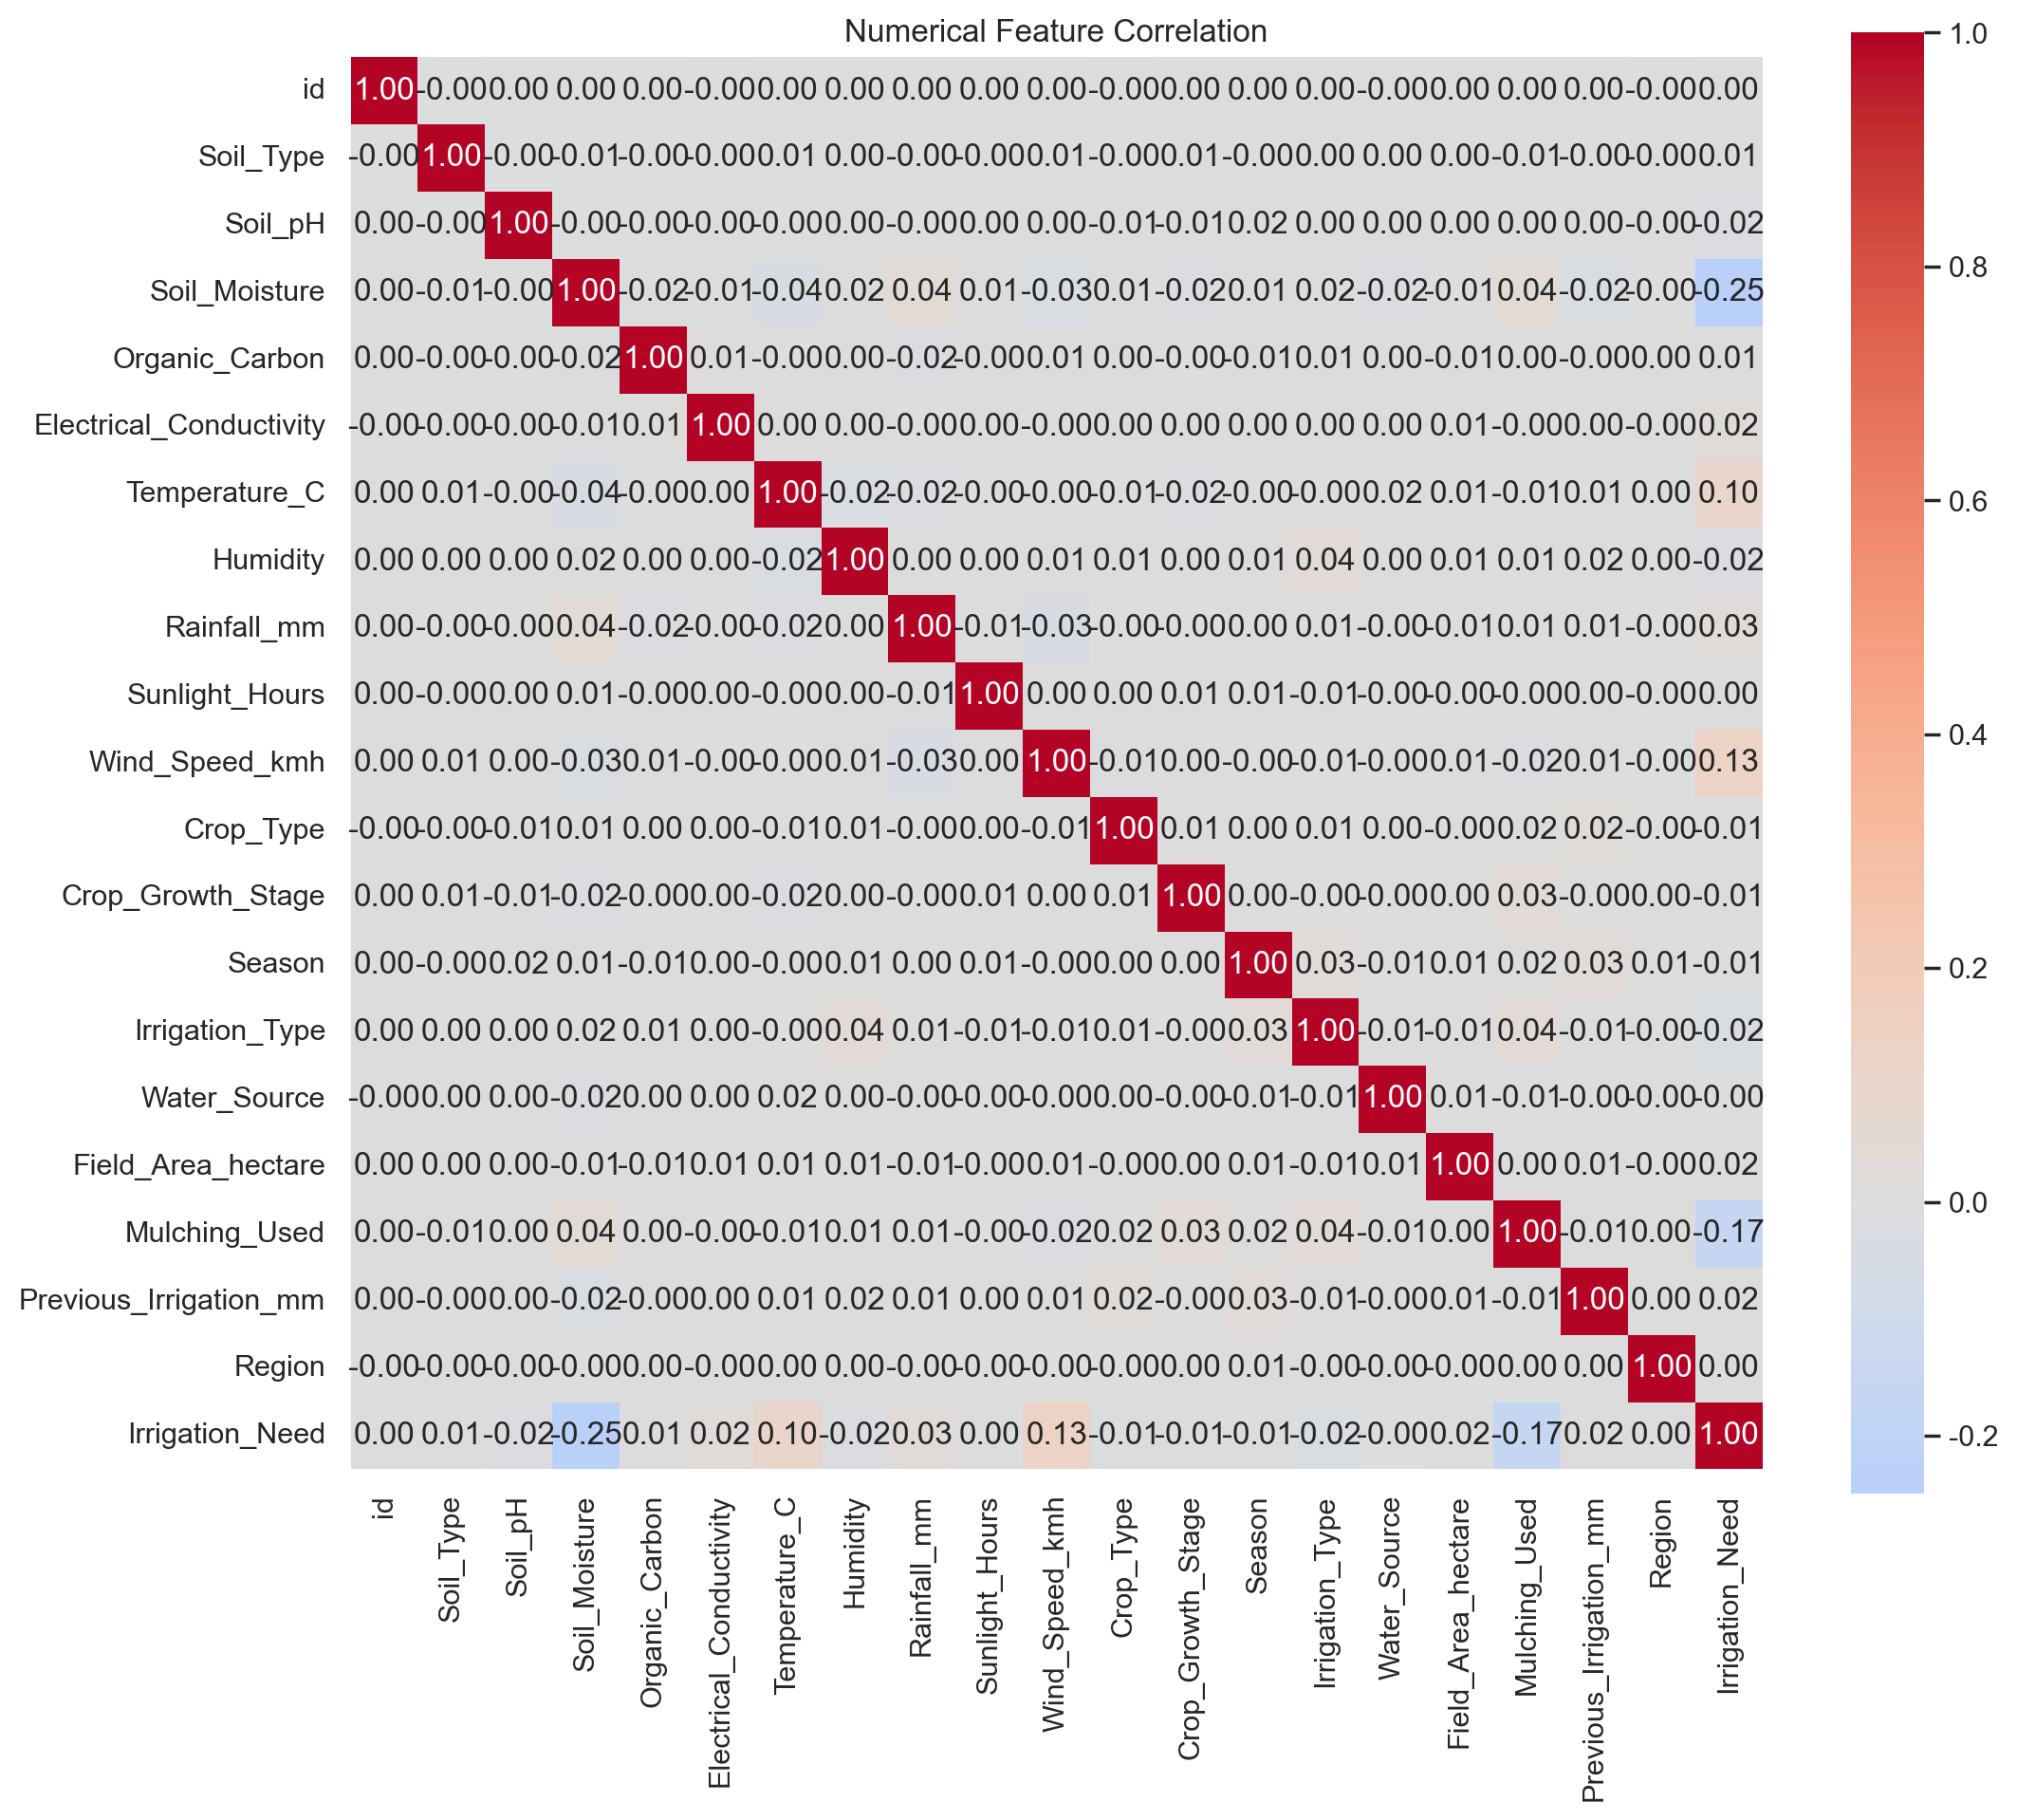

In [13]:
plt.figure(figsize=(12, 10))

# Only number type
numeric_train = train.select_dtypes(include=[np.number])
corr = numeric_train.corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0, square=True)
plt.title('Numerical Feature Correlation')
plt.show()

In [16]:
print(train.corr()['Irrigation_Need'].sort_values(ascending=False))

Irrigation_Need            1.000
Wind_Speed_kmh             0.129
Temperature_C              0.099
Rainfall_mm                0.027
Electrical_Conductivity    0.022
Field_Area_hectare         0.018
Previous_Irrigation_mm     0.016
Soil_Type                  0.006
Organic_Carbon             0.006
Sunlight_Hours             0.004
Region                     0.002
id                         0.000
Water_Source              -0.005
Crop_Type                 -0.006
Crop_Growth_Stage         -0.010
Season                    -0.012
Humidity                  -0.018
Soil_pH                   -0.019
Irrigation_Type           -0.022
Mulching_Used             -0.170
Soil_Moisture             -0.250
Name: Irrigation_Need, dtype: float64
